In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# features and target
X = adult.data.features
y = adult.data.targets

print(X.head())
print(y.head())

import pandas as pd

df = pd.concat([X, y], axis=1)
df.head()

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0          2174             0              40  United-States  
1             0             0              13  United-St

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.head())

(48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
age                 0
workclass         963
fnlwgt              0
education 

In [6]:
df = df.replace("?", np.nan)
df = df.replace(" ?", np.nan)

In [7]:
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [8]:
print(y.columns)
print(df.iloc[:, -5:].head())

Index(['income'], dtype='object')
   capital-gain  capital-loss  hours-per-week native-country income
0          2174             0              40  United-States  <=50K
1             0             0              13  United-States  <=50K
2             0             0              40  United-States  <=50K
3             0             0              40  United-States  <=50K
4             0             0              40           Cuba  <=50K


In [9]:
target_col = y.columns[0]

df[target_col] = df[target_col].astype(str).str.strip()
df[target_col] = df[target_col].replace({">50K": 1, "<=50K": 0, ">50K.": 1, "<=50K.": 0})

/tmp/ipykernel_28175/1896804419.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_col] = df[target_col].replace({">50K": 1, "<=50K": 0, ">50K.": 1, "<=50K.": 0})


In [10]:
print(df[target_col].value_counts())

income
0    37155
1    11687
Name: count, dtype: int64


In [11]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [12]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [18]:
dt_param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5],
    "model__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

start = time.time()
dt_grid.fit(X_train, y_train)
dt_train_time = time.time() - start

print("Best DT params:", dt_grid.best_params_)
print("Best DT CV score:", dt_grid.best_score_)

Best DT params: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best DT CV score: 0.6543945546411016


In [19]:
bag_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

In [20]:
bag_param_grid = {
    "model__n_estimators": [10, 50],  # reduced
    "model__max_samples": [0.8, 1.0],  # reduced
    "model__estimator__max_depth": [5, None],  # reduced
    "model__estimator__min_samples_leaf": [1, 5]
}

bag_grid = GridSearchCV(
    bag_pipeline,
    bag_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

start = time.time()
bag_grid.fit(X_train, y_train)
bag_train_time = time.time() - start

print("Best Bagging params:", bag_grid.best_params_)
print("Best Bagging CV score:", bag_grid.best_score_)

Best Bagging params: {'model__estimator__max_depth': None, 'model__estimator__min_samples_leaf': 5, 'model__max_samples': 1.0, 'model__n_estimators': 50}
Best Bagging CV score: 0.6813790172936296


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [23]:
rf_param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, None],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

start = time.time()
rf_grid.fit(X_train, y_train)
rf_train_time = time.time() - start

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score:", rf_grid.best_score_)

Best RF params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best RF CV score: 0.6729898560743448


In [24]:
def evaluate_model(name, model, X_test, y_test):
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start

    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Inference_Time": inference_time
    }

    return results, y_pred, y_prob

In [25]:
dt_results, dt_pred, dt_prob = evaluate_model(
    "Decision Tree", dt_grid.best_estimator_, X_test, y_test
)

bag_results, bag_pred, bag_prob = evaluate_model(
    "Bagging", bag_grid.best_estimator_, X_test, y_test
)

rf_results, rf_pred, rf_prob = evaluate_model(
    "Random Forest", rf_grid.best_estimator_, X_test, y_test
)

In [26]:
results_df = pd.DataFrame([dt_results, bag_results, rf_results])
results_df["Train_Time"] = [dt_train_time, bag_train_time, rf_train_time]

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Inference_Time,Train_Time
0,Decision Tree,0.861501,0.787172,0.577417,0.666173,0.898849,0.144404,80.944943
1,Bagging,0.861501,0.756644,0.621044,0.682171,0.912600,0.447599,631.011138
2,Random Forest,0.866619,0.789268,0.603935,0.684274,0.918041,0.308487,387.012484


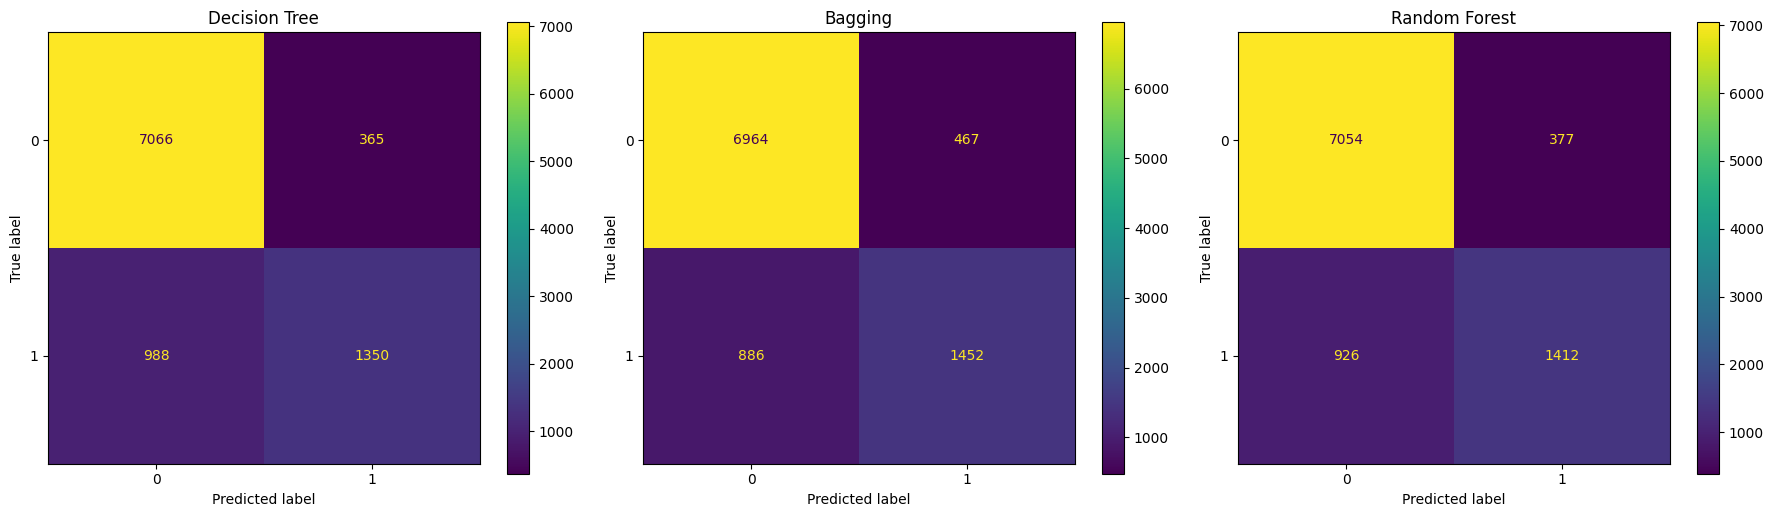

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, ax=axes[0])
axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(y_test, bag_pred, ax=axes[1])
axes[1].set_title("Bagging")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[2])
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

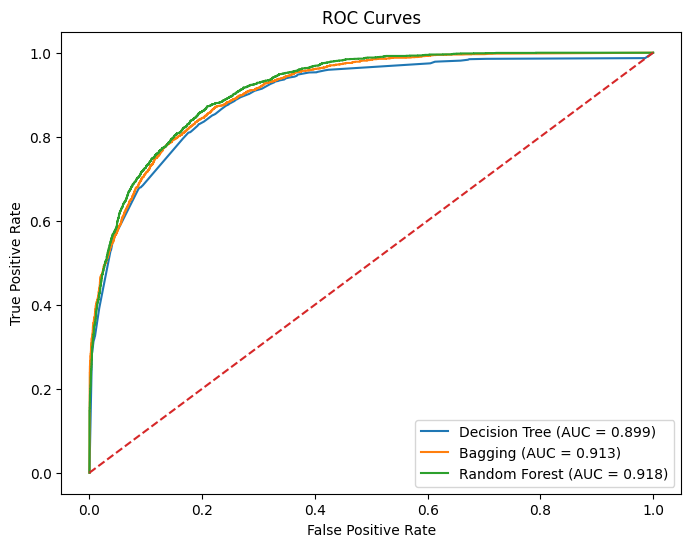

In [28]:
plt.figure(figsize=(8, 6))

for name, y_prob in [
    ("Decision Tree", dt_prob),
    ("Bagging", bag_prob),
    ("Random Forest", rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

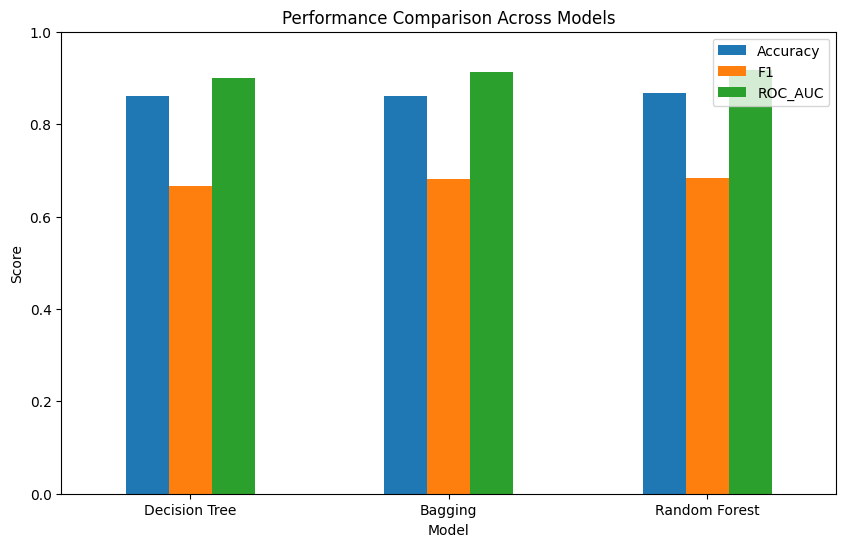

In [29]:
plot_df = results_df.set_index("Model")[["Accuracy", "F1", "ROC_AUC"]]
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Performance Comparison Across Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

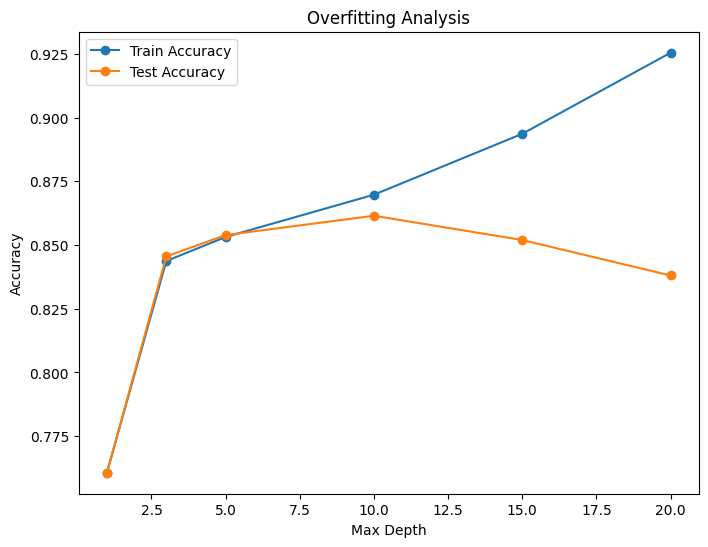

In [30]:
depths = [1, 3, 5, 10, 15, 20]
train_scores = []
test_scores = []

for depth in depths:
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 6))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")
plt.legend()
plt.show()

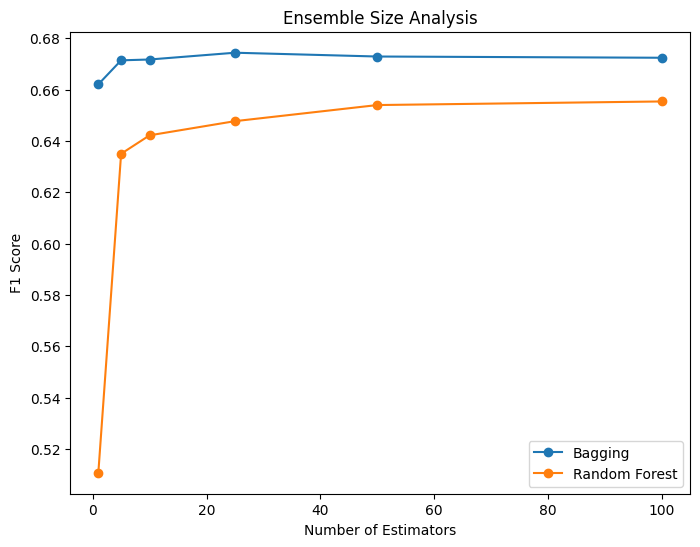

In [31]:
estimators_list = [1, 5, 10, 25, 50, 100]
bag_scores = []
rf_scores = []

for n in estimators_list:
    bag_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
            n_estimators=n,
            random_state=42
        ))
    ])
    bag_model.fit(X_train, y_train)
    bag_scores.append(f1_score(y_test, bag_model.predict(X_test)))

    rf_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=n,
            max_depth=10,
            random_state=42
        ))
    ])
    rf_model.fit(X_train, y_train)
    rf_scores.append(f1_score(y_test, rf_model.predict(X_test)))

plt.figure(figsize=(8, 6))
plt.plot(estimators_list, bag_scores, marker="o", label="Bagging")
plt.plot(estimators_list, rf_scores, marker="o", label="Random Forest")
plt.xlabel("Number of Estimators")
plt.ylabel("F1 Score")
plt.title("Ensemble Size Analysis")
plt.legend()
plt.show()

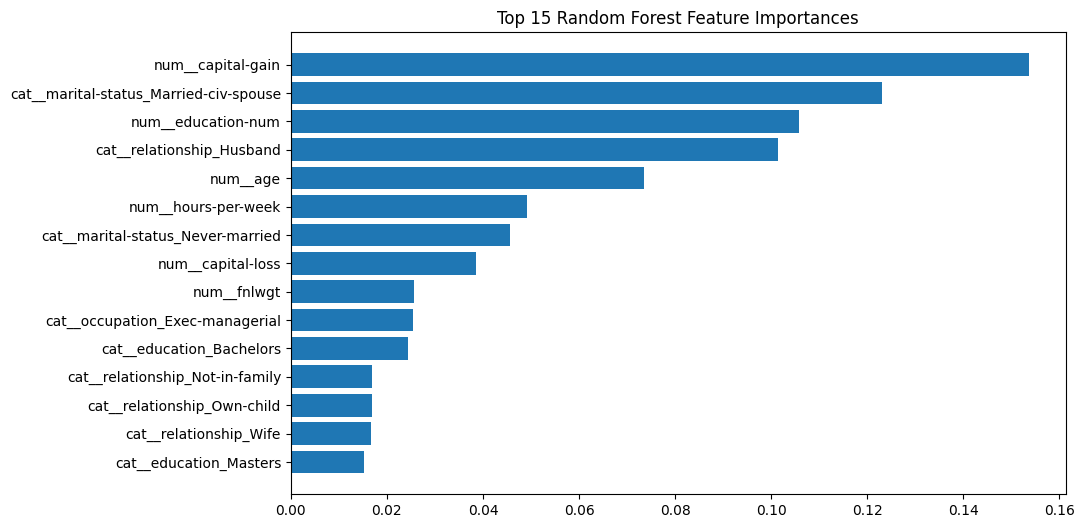

In [32]:
best_rf = rf_grid.best_estimator_
rf_model = best_rf.named_steps["model"]
rf_feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

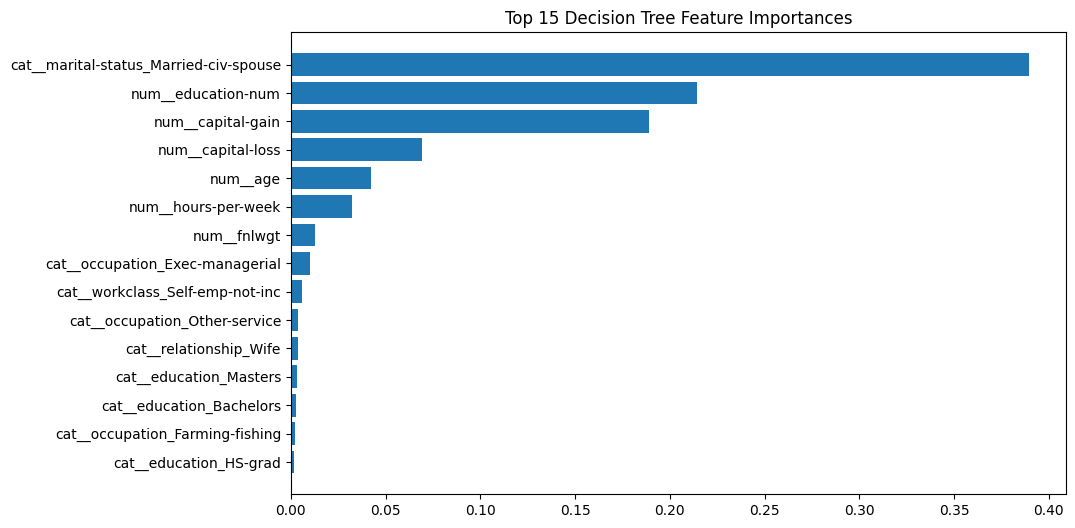

In [33]:
best_dt = dt_grid.best_estimator_
dt_model = best_dt.named_steps["model"]
dt_feature_names = best_dt.named_steps["preprocessor"].get_feature_names_out()

dt_importance_df = pd.DataFrame({
    "Feature": dt_feature_names,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(dt_importance_df["Feature"], dt_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Decision Tree Feature Importances")
plt.show()